# 15 — KITTI LiDAR–camera BEV fusion

This notebook combines the validated projection and aggregation stages into one model-ready tensor.

- Painted points: `(N_visible, 7)` containing `x, y, z, intensity, r, g, b`
- Fused BEV: `(7, 350, 400)` containing LiDAR height/density/intensity, camera RGB, and camera visibility

The reusable implementation is in `src.preprocessing.fusion`.

## 1. Data setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / "src").is_dir() else CURRENT_DIRECTORY.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset
from src.preprocessing.fusion import (
    FUSED_BEV_CHANNELS,
    build_fused_bev,
    paint_lidar_points_with_rgb,
)

In [2]:
dataset = KittiDataset(
    root=PROJECT_ROOT / "data" / "KITTI",
    split="training",
    load_images=True,
)
sample = dataset[0]
lidar_points = sample["points"]
image = sample["image"]
calibration = sample["calib"]

print("Sample:", sample["id"])
print("LiDAR:", lidar_points.shape, lidar_points.dtype)
print("Image:", image.shape, image.dtype)
print("Labels:", len(sample["labels"]))

Sample: 000000
LiDAR: (115384, 4) float32
Image: (370, 1224, 3) uint8
Labels: 1


## 2. Paint LiDAR points with camera RGB

Each LiDAR point is projected into the image. The normalized RGB value at the matched pixel is attached to the original point. This creates point-level fusion, not the final BEV.

In [3]:
painted_points, pixels, depths = paint_lidar_points_with_rgb(
    points=lidar_points,
    image=image,
    calibration=calibration,
)

print("Original points:", len(lidar_points))
print("Visible painted points:", painted_points.shape)
print("Pixels:", pixels.shape)
print("Depths:", depths.shape)
print("Columns: x, y, z, intensity, red, green, blue")
print("First row:", painted_points[0])

assert painted_points.shape[1] == 7
assert len(painted_points) == len(pixels) == len(depths)
assert np.isfinite(painted_points).all()

Original points: 115384
Visible painted points: (20285, 7)
Pixels: (20285, 2)
Depths: (20285,)
Columns: x, y, z, intensity, red, green, blue
First row: [18.324       0.049       0.829       0.          0.07058824  0.07843138
  0.10196079]


### Check the LiDAR-to-camera projection

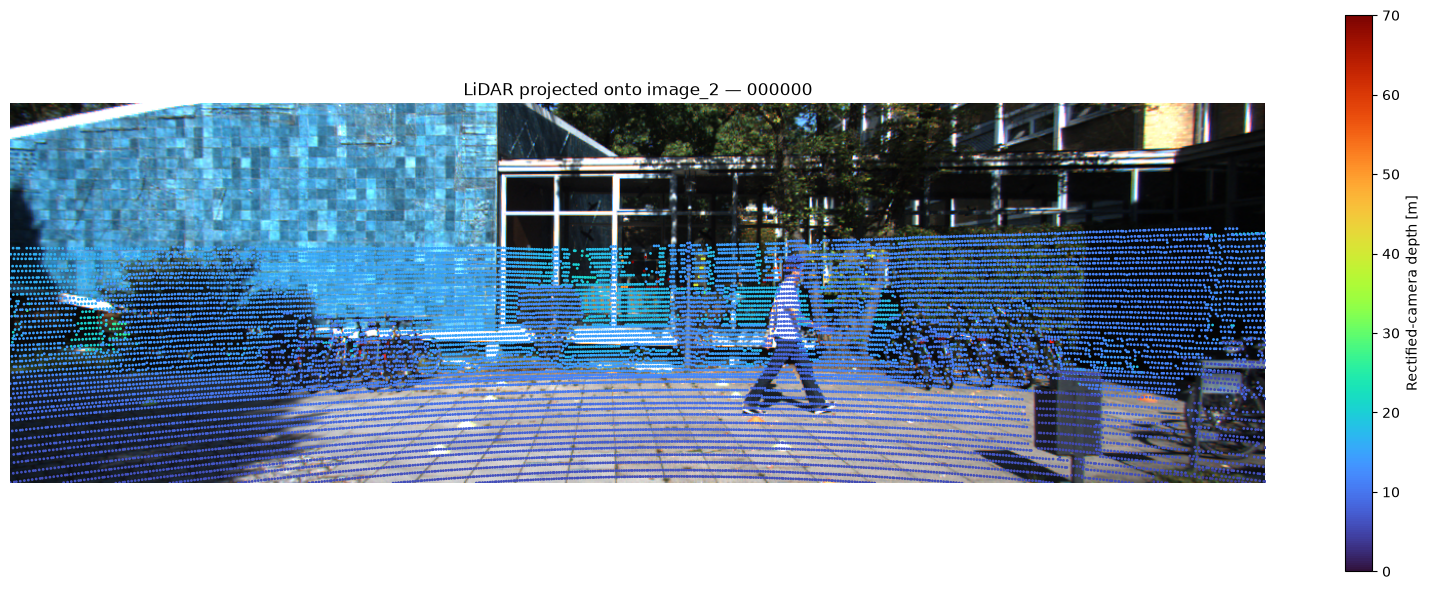

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(image)
scatter = ax.scatter(
    pixels[:, 0], pixels[:, 1],
    c=depths, s=1, cmap="turbo", vmin=0, vmax=70,
)
ax.set_xlim(0, image.shape[1])
ax.set_ylim(image.shape[0], 0)
ax.set_title(f"LiDAR projected onto image_2 — {sample['id']}")
ax.axis("off")
fig.colorbar(scatter, ax=ax, label="Rectified-camera depth [m]")
fig.tight_layout()
plt.show()

### Check the camera-coloured LiDAR geometry

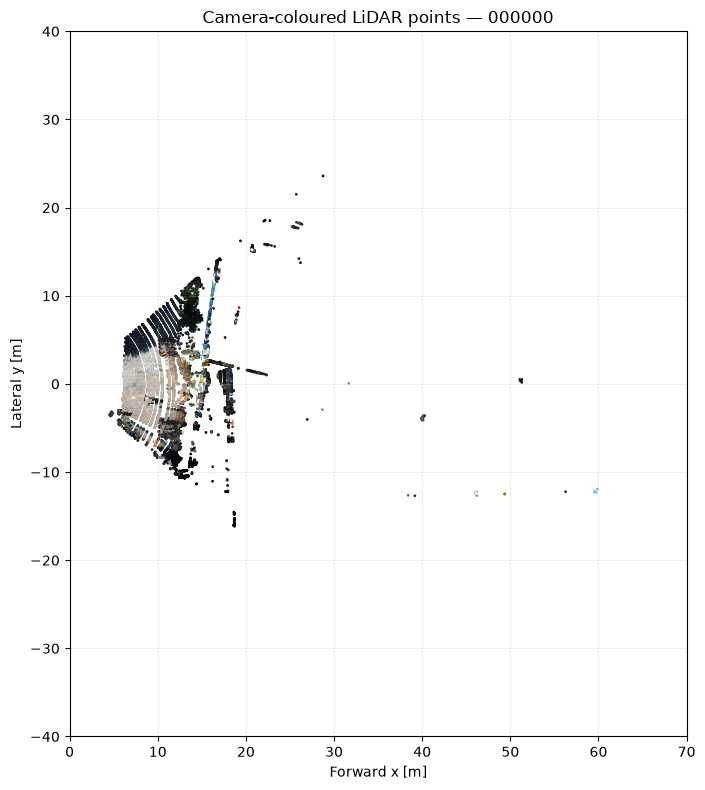

In [5]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(
    painted_points[:, 0],
    painted_points[:, 1],
    c=painted_points[:, 4:7],
    s=1,
)
ax.set_xlim(0, 70)
ax.set_ylim(-40, 40)
ax.set_aspect("equal")
ax.set_xlabel("Forward x [m]")
ax.set_ylabel("Lateral y [m]")
ax.set_title(f"Camera-coloured LiDAR points — {sample['id']}")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 3. Build the model-ready fused BEV

The module independently builds the 3-channel LiDAR BEV and 4-channel camera BEV on the same metric grid, then concatenates them into `(7, 350, 400)`.

In [6]:
fused_bev = build_fused_bev(
    points=lidar_points,
    image=image,
    calibration=calibration,
)

print("Fused BEV:", fused_bev.shape, fused_bev.dtype)
print("Finite:", np.isfinite(fused_bev).all())

for index, name in enumerate(FUSED_BEV_CHANNELS):
    channel = fused_bev[index]
    print(
        f"{index}: {name:20s}",
        f"min={channel.min():.3f}",
        f"max={channel.max():.3f}",
        f"nonzero={np.count_nonzero(channel)}",
    )

assert fused_bev.shape == (7, 350, 400)
assert fused_bev.dtype == np.float32
assert np.isfinite(fused_bev).all()
assert np.all((fused_bev[3:6] >= 0) & (fused_bev[3:6] <= 1))
assert np.all((fused_bev[6] == 0) | (fused_bev[6] == 1))

Fused BEV: (7, 350, 400) float32
Finite: True
0: lidar_height         min=0.000 max=0.824 nonzero=6324
1: lidar_density        min=0.000 max=1.000 nonzero=6324
2: lidar_intensity      min=0.000 max=0.990 nonzero=5976
3: camera_red           min=0.000 max=1.000 nonzero=2611
4: camera_green         min=0.000 max=1.000 nonzero=2611
5: camera_blue          min=0.000 max=1.000 nonzero=2611
6: camera_visibility    min=0.000 max=1.000 nonzero=2611


## 4. Compare LiDAR and camera BEV alignment

The camera BEV is expected to be sparse: RGB is transferred only where a visible LiDAR return exists. The visibility channel distinguishes observed black pixels from unobserved cells.

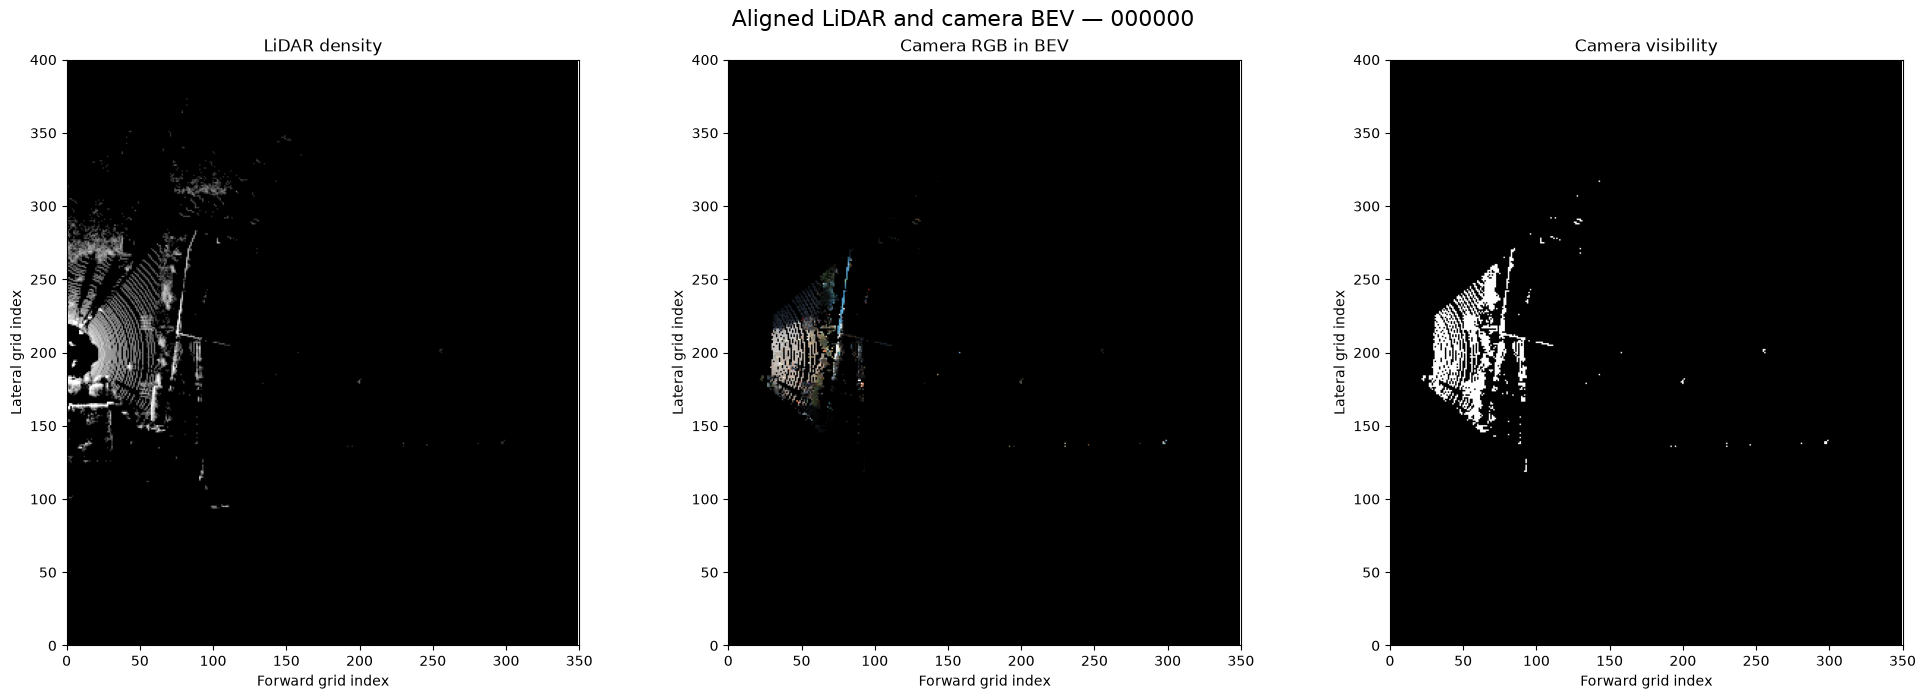

In [7]:
camera_rgb_bev = np.transpose(fused_bev[3:6], (2, 1, 0))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(fused_bev[1].T, origin="lower", cmap="gray", aspect="equal")
axes[0].set_title("LiDAR density")
axes[1].imshow(camera_rgb_bev, origin="lower", aspect="equal")
axes[1].set_title("Camera RGB in BEV")
axes[2].imshow(fused_bev[6].T, origin="lower", cmap="gray", aspect="equal")
axes[2].set_title("Camera visibility")

for ax in axes:
    ax.set_xlim(0, fused_bev.shape[1])
    ax.set_ylim(0, fused_bev.shape[2])
    ax.set_xlabel("Forward grid index")
    ax.set_ylabel("Lateral grid index")

fig.suptitle(f"Aligned LiDAR and camera BEV — {sample['id']}", fontsize=16)
fig.tight_layout()
plt.show()

## 5. Inspect all seven model input channels

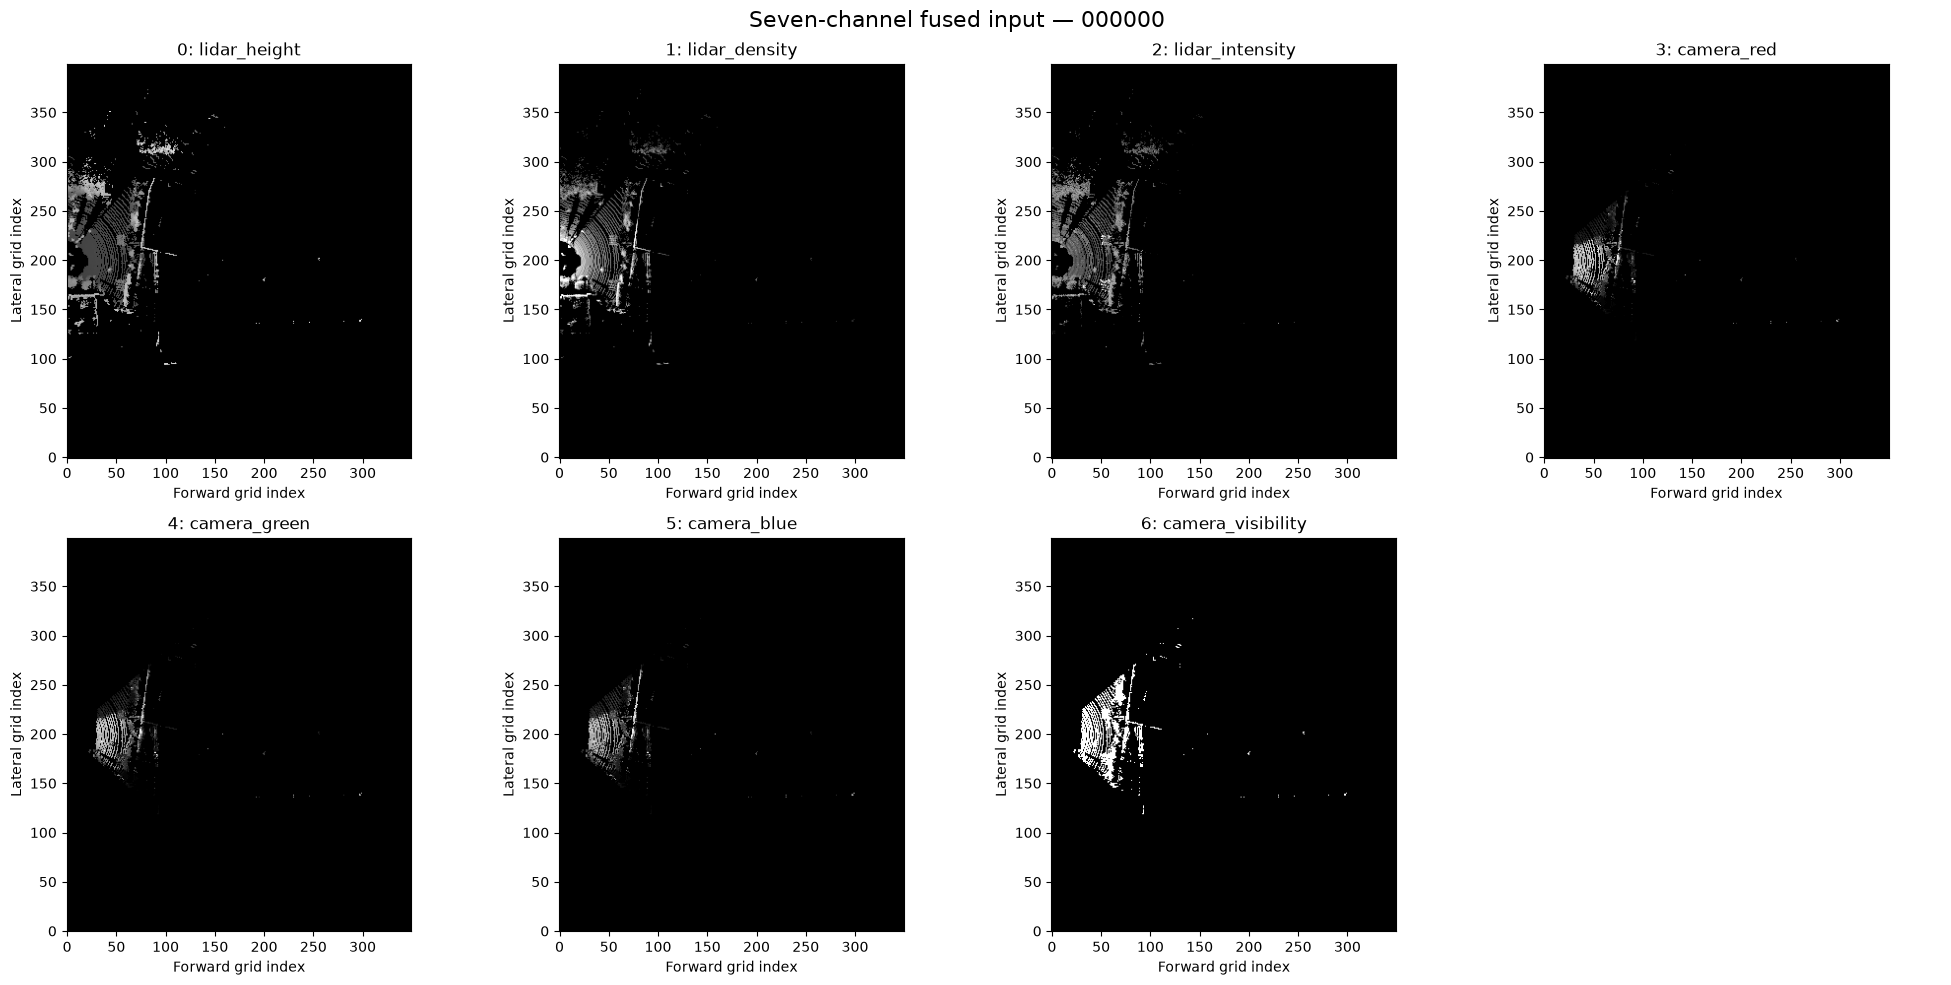

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for channel_index, ax in enumerate(axes.flat):
    if channel_index >= len(FUSED_BEV_CHANNELS):
        ax.axis("off")
        continue
    ax.imshow(
        fused_bev[channel_index].T,
        origin="lower",
        cmap="gray",
        aspect="equal",
    )
    ax.set_title(f"{channel_index}: {FUSED_BEV_CHANNELS[channel_index]}")
    ax.set_xlabel("Forward grid index")
    ax.set_ylabel("Lateral grid index")

fig.suptitle(f"Seven-channel fused input — {sample['id']}", fontsize=16)
fig.tight_layout()
plt.show()

## 6. Structural check across several frames

In [9]:
for sample_index in [0, 1, 2, 10, 50]:
    check_sample = dataset[sample_index]
    check_bev = build_fused_bev(
        points=check_sample["points"],
        image=check_sample["image"],
        calibration=check_sample["calib"],
    )
    print(
        f"sample={check_sample['id']}",
        f"shape={check_bev.shape}",
        f"finite={np.isfinite(check_bev).all()}",
        f"visible cells={int(check_bev[6].sum())}",
    )

sample=000000 shape=(7, 350, 400) finite=True visible cells=2611
sample=000001 shape=(7, 350, 400) finite=True visible cells=5808
sample=000002 shape=(7, 350, 400) finite=True visible cells=2584
sample=000010 shape=(7, 350, 400) finite=True visible cells=4780
sample=000050 shape=(7, 350, 400) finite=True visible cells=2769


## Result and next step

Fusion preprocessing is ready when projection alignment is correct across several frames and every sample produces a finite `float32` tensor of shape `(7, 350, 400)`.

Next, make `BEVDetector` accept configurable `input_channels`: keep 3 for the LiDAR baseline and use 7 for fusion. Validate one forward/backward pass before starting training.